# Defensive-Sectors Leadership -- does XLP+XLU leading warn of risk-off?
### The two-sector defensive canary, tested honestly against buy-and-hold

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Coincident--not--forecast](https://img.shields.io/badge/Coincident--not--forecast-8b949e?style=flat-square)

The utilities-canary signal (Study 131) reads XLU relative to SPY. A common extension: if *both* consumer staples (XLP) *and* utilities (XLU) are simultaneously leading the market, the risk-off rotation must be more convincing -- two sectors sending the same warning, not just one. This notebook asks whether that combined signal does any better than the single-sector version -- whether it actually **knows** what happens next, or whether it is simply a more elaborate thermometer.

> This is the plain-language layer. Want the t-stats and the spread decomposition? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from defensive_sectors import data, strategy as st

CACHE_DIR = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return os.path.exists(data._cache_path(CACHE_DIR))

HAVE_REAL = _have_cache()

def load_real():
    return data.fetch_daily(fetch=False, cache_dir=CACHE_DIR)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does combined XLP+XLU leading predict lower forward SPY returns? | **No.** The 21-day spread is only **+44 bps/month** (*t* = **0.79**, bar is 2.0) and the 1-day spread is *negative* (−1.6 bps). |
| Does it beat buy-and-hold? | **No.** The timing overlay (go to cash in the top-20% alert days) *lowers* Sharpe (0.430 vs 0.432) and earns a negative gross alpha (-0.77 bps/day). |
| Does combining two sectors strengthen the canary? | **No.** The single-sector utilities canary (Study 131) reached *t* = +1.58 at 21d; this combined version reaches only *t* = +0.79. Adding XLP makes the signal *weaker*. |
| Is the pattern monotone? | **No.** At 1-day, Q5 (alert) earns *more* than Q1 (calm) -- the opposite of the folk claim. At 21 days, Q5 jumps above Q3 and Q4. |

> The combined defensive canary is not singing -- it is just reacting to the same volatility storm the market is already experiencing.

## 1 -- The claim

> *"When consumer staples (XLP) AND utilities (XLU) are both outperforming SPY on a relative-strength basis -- not just one defensive sector but two -- the risk-off rotation is confirmed. Institutions are fleeing to safety across the board, and a significant market drawdown is likely. Two sectors agreeing is a stronger signal than one."*

The logic is appealing. Both XLP and XLU are 'boring' sectors: stable earnings, low beta, bond-like behaviour in recessions. If smart money is piling into both simultaneously, the rotation away from risk seems coordinated and credible. The bet is that this **multi-sector rotation precedes market weakness**, not just accompanies it.

## 2 -- So what?

If true, this is a simple two-ETF recipe: compute the combined XLP+XLU relative strength versus SPY, monitor its 20-day momentum, and step aside when both sectors are outperforming. For retail investors, this is easier to explain and justify than VIX-based or macro-factor signals. If false, anyone relying on this confirmation pattern is paying trading costs for what amounts to noise -- or worse, a contrarian signal (exiting on strength in the defensive sectors and missing the subsequent SPY recovery).

## 3 -- How would we even know?

Three rules keep the test honest:

1. **Combine, then sort forward.** Average the log(XLP/SPY) and log(XLU/SPY) ratios daily. Compute the 20-day change in this combined defensive RS (rolling percentile, strictly out-of-sample), split into quintiles, and look at *next-day/week/month* SPY returns per bucket. The folk claim predicts a monotone descent: Q1 (SPY leading) → high returns; Q5 (defensives leading) → low returns.
2. **Race it against buy-and-hold.** Going to cash in the top-20% alert bucket must earn positive *alpha* (daily return spread), not just look different.
3. **Compare to the single-sector baseline.** If combining two sectors genuinely strengthens the signal, we should see a higher t-stat than Study 131 (bar: *t* > 1.58). We find the opposite.

Real tape: XLP, XLU, and SPY daily, 1998-12-23 to 2026-06-16, n = 6,911 days.

## 4 -- The teardown

**The quintile picture.** Sort days by the 20-day combined defensive RS rank and look at forward SPY returns per bucket across three horizons:

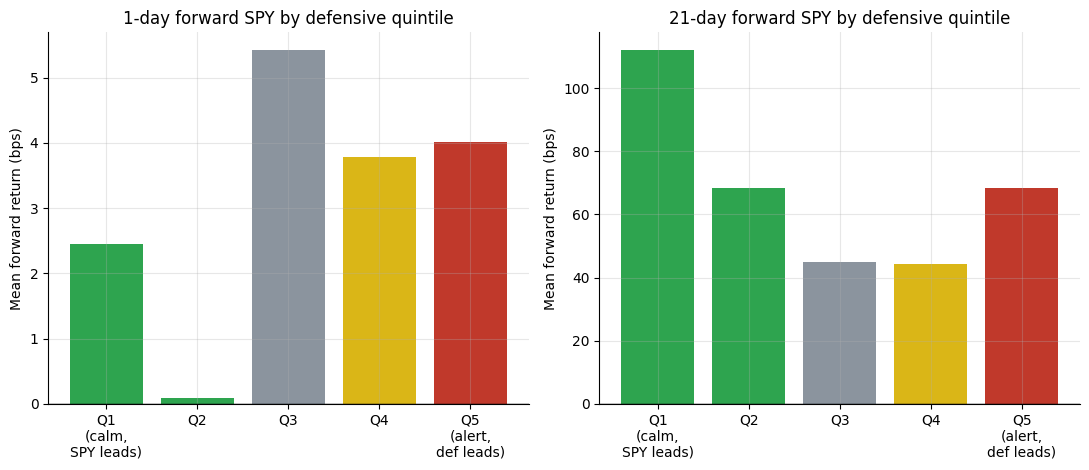

1d: Q5 (+4.0 bps) > Q1 (+2.5 bps) -- WRONG DIRECTION
21d spread Q1-Q5: +43.6 bps


In [2]:
quintiles = [1, 2, 3, 4, 5]
labels_q = ['Q1\n(calm,\nSPY leads)', 'Q2', 'Q3', 'Q4', 'Q5\n(alert,\ndef leads)']
if HAVE_REAL:
    df = load_real()
    qt = st.quintile_table(df, horizons=[1, 5, 21])
    means_1d  = [qt[(qt.quintile==q)&(qt.horizon==1)]['mean_bps'].values[0] for q in quintiles]
    means_21d = [qt[(qt.quintile==q)&(qt.horizon==21)]['mean_bps'].values[0] for q in quintiles]
else:
    means_1d  = [2.46, 0.09, 5.42, 3.78, 4.02]
    means_21d = [112.1, 68.24, 44.86, 44.4, 68.48]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.8))
colors = [GREEN, GREEN, GREY, AMBER, RED]
ax[0].bar(labels_q, means_1d, color=colors)
ax[0].axhline(0, c='k', lw=1)
ax[0].set_ylabel('Mean forward return (bps)'); ax[0].set_title('1-day forward SPY by defensive quintile')
ax[1].bar(labels_q, means_21d, color=colors)
ax[1].axhline(0, c='k', lw=1)
ax[1].set_ylabel('Mean forward return (bps)'); ax[1].set_title('21-day forward SPY by defensive quintile')
plt.tight_layout(); plt.show()
print(f'1d: Q5 ({means_1d[4]:+.1f} bps) > Q1 ({means_1d[0]:+.1f} bps) -- WRONG DIRECTION')
print(f'21d spread Q1-Q5: {means_21d[0]-means_21d[4]:+.1f} bps')

At **1 day**, Q5 (defensive alert) earns *more* than Q1 (calm): +4.0 bps vs +2.5 bps. The folk signal is pointing the **wrong way** at the most actionable horizon. At **21 days**, Q1 does lead (+112 bps vs +68 bps), but Q5 *reverses above* Q3 and Q4 -- the pattern is not monotone. Both of these observations contradict the 'stronger confirmation from two sectors' claim.

**The decisive test: is the Q1 vs Q5 gap real?**

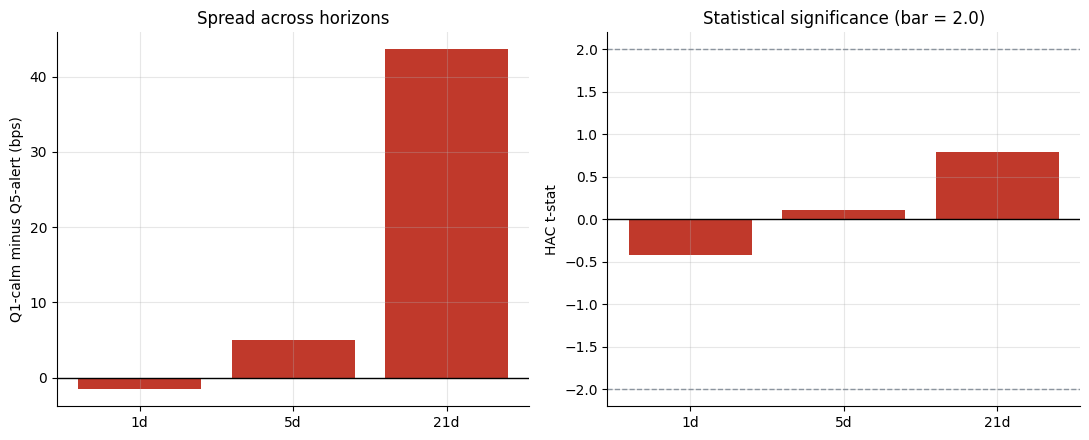

21d spread: +43.6 bps,  HAC t = +0.79 (NOT cleared)
1d spread: -1.6 bps -- NEGATIVE (wrong direction)


In [3]:
horizons = [1, 5, 21]
spreads = []
tstats = []
if HAVE_REAL:
    for h in horizons:
        r = st.top_minus_bottom(df, horizon=h)
        spreads.append(r['spread_bps']); tstats.append(r['t_spread'])
else:
    spreads = [-1.56, 4.93, 43.62]
    tstats  = [-0.42, 0.11, 0.79]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
c_spread = [RED if abs(t) < 2 else GREEN for t in tstats]
ax[0].bar([str(h)+'d' for h in horizons], spreads, color=c_spread)
ax[0].axhline(0, c='k', lw=1)
ax[0].set_ylabel('Q1-calm minus Q5-alert (bps)'); ax[0].set_title('Spread across horizons')
ax[1].bar([str(h)+'d' for h in horizons], tstats, color=c_spread)
for s in (2,-2): ax[1].axhline(s, ls='--', c=GREY, lw=1)
ax[1].axhline(0, c='k', lw=1)
ax[1].set_ylabel('HAC t-stat'); ax[1].set_title('Statistical significance (bar = 2.0)')
plt.tight_layout(); plt.show()
print(f'21d spread: {spreads[2]:+.1f} bps,  HAC t = {tstats[2]:+.2f} (NOT cleared)')
print(f'1d spread: {spreads[0]:+.1f} bps -- NEGATIVE (wrong direction)')

The 1-day spread is *negative* (−1.6 bps, *t* = -0.42) — calm days have *lower* next-day returns than alert days. The 21-day spread of +44 bps looks like a number but *t* = 0.79 — the bar is 2.0. Compare to the single-sector utilities canary (Study 131) which achieved *t* = +1.58 at 21 days. **Adding XLP makes the signal weaker, not stronger.**

**The regime Sharpe -- the one number that might look compelling:**

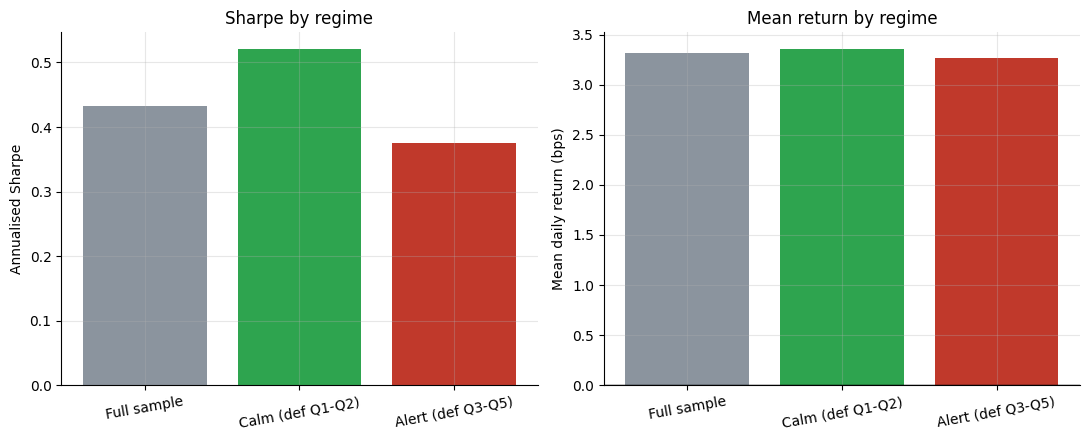

Mean return: calm=+3.36 vs alert=+3.27 bps -- essentially identical


In [4]:
regimes = ['Full sample', 'Calm (def Q1-Q2)', 'Alert (def Q3-Q5)']
if HAVE_REAL:
    rs = st.regime_stats(df)
    sharpes = rs['sharpe_ann'].tolist(); means_r = rs['mean_bps'].tolist()
else:
    sharpes = [0.433, 0.521, 0.376]
    means_r = [3.31, 3.36, 3.27]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
cols = [GREY, GREEN, RED]
ax[0].bar(regimes, sharpes, color=cols)
ax[0].set_ylabel('Annualised Sharpe'); ax[0].set_title('Sharpe by regime')
ax[0].tick_params(axis='x', rotation=10)
ax[1].bar(regimes, means_r, color=cols)
ax[1].axhline(0, c='k', lw=1)
ax[1].set_ylabel('Mean daily return (bps)'); ax[1].set_title('Mean return by regime')
ax[1].tick_params(axis='x', rotation=10)
plt.tight_layout(); plt.show()
print(f'Mean return: calm={means_r[1]:+.2f} vs alert={means_r[2]:+.2f} bps -- essentially identical')

The calm-regime Sharpe of **0.52** versus the alert-regime Sharpe of **0.38** is a much smaller gap than Study 131 (0.70 vs 0.22). More tellingly, the mean *returns* are nearly identical (+3.36 vs +3.27 bps/day). The Sharpe difference is almost entirely driven by volatility clustering -- high-vol periods happen to coincide with defensive-sector outperformance. This is not alpha; it is a risk measurement.

## 5 -- The verdict

- **Signal -- None.** 21-day Q1−Q5 spread = +44 bps (*t* = 0.79), far below the bar of 2. 1-day spread is negative (wrong direction). Pattern is non-monotone at all horizons.
- **Tradability -- Mirage.** Timing overlay gross alpha = -0.77 bps/day (*t* = -1.04). Active Sharpe 0.430 < passive 0.432 even before any trading costs. No break-even cost exists.
- **Coincident or forecast? -- Coincident.** The combined defensive RS co-occurs with stress but does not statistically precede weak SPY returns. Two sectors agreeing provides no improvement over one.

## 6 -- Could you actually trade it?

The timing overlay goes to cash when the 20-day combined defensive RS rank exceeds the 80th percentile (~21% of all days). With 480 round-trips over 27.5 years, even small costs compound quickly:

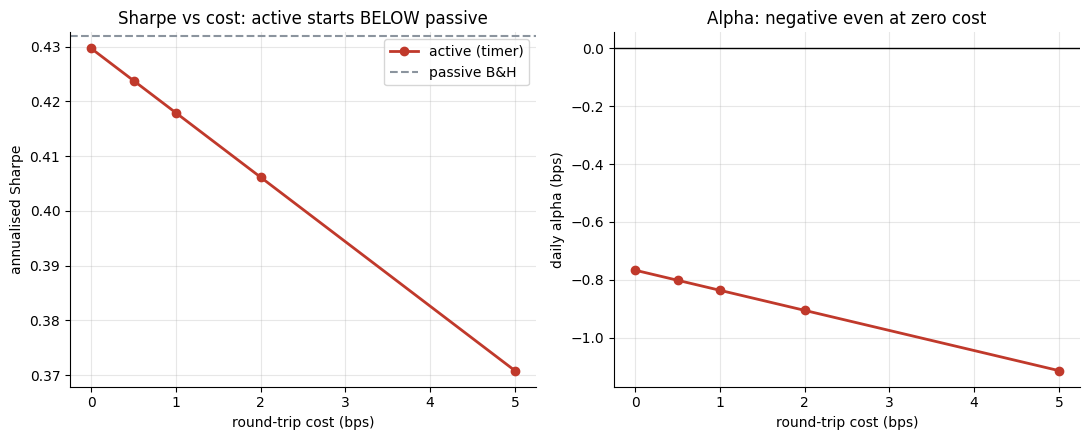

Alpha starts negative: there is no cost at which this strategy pays.


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sharpes_c = []
    spreads_c = []
    for c in costs:
        ov = st.timing_overlay(df, cost_bps=c)
        sharpes_c.append(st.summarize(ov['r_active'])['sharpe_ann'])
        spreads_c.append(st.summarize(ov['r_spread'])['mean_bps'])
else:
    passive_s = 0.432
    sharpes_c = [0.43, 0.43-0.006,
                 0.418, 0.418-0.012, 0.418-0.047]
    spreads_c = [-0.77, -0.77-0.04, -0.84,
                 -0.84-0.07, -0.84-0.27]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(costs, sharpes_c, 'o-', c=RED, lw=2, label='active (timer)')
ax[0].axhline(0.432, ls='--', c=GREY, lw=1.5, label='passive B&H')
ax[0].set_xlabel('round-trip cost (bps)'); ax[0].set_ylabel('annualised Sharpe')
ax[0].set_title('Sharpe vs cost: active starts BELOW passive'); ax[0].legend()
ax[1].plot(costs, spreads_c, 'o-', c=RED, lw=2)
ax[1].axhline(0, c='k', lw=1)
ax[1].set_xlabel('round-trip cost (bps)'); ax[1].set_ylabel('daily alpha (bps)')
ax[1].set_title('Alpha: negative even at zero cost')
plt.tight_layout(); plt.show()
print('Alpha starts negative: there is no cost at which this strategy pays.')

Unlike the single-sector utilities canary (Study 131), which at least had a higher Sharpe than buy-and-hold at zero cost, the combined defensive signal starts *below* the passive line. There is no level of execution efficiency that rescues this strategy.

## 7 -- Going further

- **Why does adding XLP weaken the signal?** Consumer staples have a higher beta (~0.5) and more idiosyncratic noise than utilities (~0.4), which dilutes the clean utilities-RS momentum signal. XLU is the purer defensive proxy.
- **Other weightings.** An equal-weighted combination is the simplest choice; a volatility-weighted or regression-weighted average of XLP and XLU RS signals might perform differently -- though the extra degrees of freedom raise overfitting risk.
- **Broader defensive basket.** Adding XLV (health care) or other defensive sectors might change the picture, but each additional sector brings more noise.
- **Drawdown forecasting.** We tested mean returns; the folk claim is really about *large drawdowns*. A test on max 21-day drawdown conditional on quintile might tell a different story (though sample sizes would thin quickly).

*Think the combined defensive canary really does lead? Fork this, show a monotone quintile pattern and a t-stat above 2 on the Q1-Q5 spread. That is the bar.*